# 02 — Preprocessing for Topic Modeling

This notebook prepares the BIS central bank speeches corpus for the NLP models used in the project.

The objective is to build a clean modeling dataset that can be used in the next notebooks:

- **NMF topic modeling** with TF-IDF features;
- **LDA topic modeling** with count-based features;
- **BERTopic**, using transformer-based document embeddings;
- **Hawkish/dovish tone analysis**, using normalized dictionary scores.

The preprocessing decisions are based on the exploratory data analysis from Notebook 01. In particular, the EDA showed that the corpus contains some missing or empty texts, a small number of exact duplicates, very short documents, and generic words that should not dominate the topic models.

## 1. Imports and global settings

I start by importing the libraries used in this notebook. I keep the preprocessing code in the notebook rather than in external `.py` files to make the workflow easier to read and reproduce.

In [1]:
import re
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset
from tqdm.auto import tqdm
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

import spacy

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_colwidth", 120)
plt.rcParams["figure.figsize"] = (10, 5)


### Load spaCy model

I use spaCy for the classical topic-modeling preprocessing. This gives a cleaner linguistic pipeline than a simple whitespace split: tokenization, lemmatization and part-of-speech filtering.

In [2]:

try:
    nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])
except OSError as exc:
    raise OSError(
        "spaCy model 'en_core_web_sm' is not installed. "
        "Run: python -m spacy download en_core_web_sm"
    ) from exc

print("spaCy pipeline:", nlp.pipe_names)


spaCy pipeline: ['tok2vec', 'tagger', 'attribute_ruler', 'lemmatizer']


## 2. Load the raw dataset

The dataset is provided as a single Hugging Face split named `train`. This does not mean that I am using it as a supervised training set. It simply means that the dataset authors stored all observations in one split. Since the project focuses on unsupervised topic modeling and descriptive tone analysis, the absence of predefined validation and test splits is not an issue.

In [4]:
dataset = load_dataset("samchain/bis_central_bank_speeches")

print(dataset)
print("Available splits:", list(dataset.keys()))

df = dataset["train"].to_pandas()

print("Raw shape:", df.shape)
df.head()

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/179M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/19376 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['description', 'text', 'bank', 'Year', 'Month'],
        num_rows: 19376
    })
})
Available splits: ['train']
Raw shape: (19376, 5)


,description,text,bank,Year,Month
0,"Lecture delivered in honour of Professor Xenophon Zolotas, Honorary Governor of the Bank of Greece, by the President...",Mr. Tietmeyer considers European monetary integration and its implications for the international monetary system Lec...,bank of greece,1997,10
1,"Speech given by Mr Nicholas C Garganas, Deputy Governor of the Bank of Greece, at the 'Athens Summit 1999' on 18 Sep...",Mr Garganas gives a speech on integrating Greece into the euro area and the challenges ahead Speech given by Mr Nich...,bank of greece,1999,9
2,"Address by Mr Nicholas C Garganas, Deputy Governor of the Bank of Greece, at the Euromoney International Bond Congre...",None,bank of greece,2000,3
3,"Speech by Mr Lucas Papademos, Governor of the Bank of Greece, at the Euro Information Conference, Athens, 17 October...","Lucas Papademos: The completion of the changeover to the euro Speech by Mr Lucas Papademos, Governor of the Bank of ...",bank of greece,2001,10
4,"Address by Mr Nicholas C Garganas, Deputy Governor of the Bank of Greece, to the Hellenic American Bankers Associati...","Nicholas Garganas: The Greek economy within the euro area Address by Mr Nicholas C Garganas, Deputy Governor of the ...",bank of greece,2002,5


## 3. Rename columns

The raw dataset contains five columns. I rename them to make the rest of the notebook clearer:

- `text` becomes `raw_text`;
- `bank` becomes `central_bank`;
- `Year` becomes `year`;
- `Month` becomes `month`.

The `raw_text` column is the main text field used for NLP modeling.

In [5]:
df = df.rename(columns={
    "text": "raw_text",
    "bank": "central_bank",
    "Year": "year",
    "Month": "month"
})

df.head()

,description,raw_text,central_bank,year,month
0,"Lecture delivered in honour of Professor Xenophon Zolotas, Honorary Governor of the Bank of Greece, by the President...",Mr. Tietmeyer considers European monetary integration and its implications for the international monetary system Lec...,bank of greece,1997,10
1,"Speech given by Mr Nicholas C Garganas, Deputy Governor of the Bank of Greece, at the 'Athens Summit 1999' on 18 Sep...",Mr Garganas gives a speech on integrating Greece into the euro area and the challenges ahead Speech given by Mr Nich...,bank of greece,1999,9
2,"Address by Mr Nicholas C Garganas, Deputy Governor of the Bank of Greece, at the Euromoney International Bond Congre...",None,bank of greece,2000,3
3,"Speech by Mr Lucas Papademos, Governor of the Bank of Greece, at the Euro Information Conference, Athens, 17 October...","Lucas Papademos: The completion of the changeover to the euro Speech by Mr Lucas Papademos, Governor of the Bank of ...",bank of greece,2001,10
4,"Address by Mr Nicholas C Garganas, Deputy Governor of the Bank of Greece, to the Hellenic American Bankers Associati...","Nicholas Garganas: The Greek economy within the euro area Address by Mr Nicholas C Garganas, Deputy Governor of the ...",bank of greece,2002,5


## 4. Recreate useful metadata

The EDA introduced broad macro-financial periods to help interpret the temporal evolution of topics. I recreate this variable here so that the final modeling dataset contains all the metadata needed for the following notebooks.

These periods are not official labels from the dataset. They are a macroeconomic interpretation grid used only for analysis.

In [6]:
def assign_macro_period(year):
    if pd.isna(year):
        return "Unknown"
    year = int(year)
    if year <= 2006:
        return "Pre-GFC"
    elif 2007 <= year <= 2009:
        return "Global Financial Crisis"
    elif 2010 <= year <= 2014:
        return "Euro crisis / post-GFC"
    elif 2015 <= year <= 2019:
        return "Low rates / QE"
    elif 2020 <= year <= 2021:
        return "Covid"
    elif year >= 2022:
        return "Inflation tightening"
    else:
        return "Unknown"

df["macro_period"] = df["year"].apply(assign_macro_period)

df[["year", "month", "macro_period", "central_bank"]].head()

,year,month,macro_period,central_bank
0,1997,10,Pre-GFC,bank of greece
1,1999,9,Pre-GFC,bank of greece
2,2000,3,Pre-GFC,bank of greece
3,2001,10,Pre-GFC,bank of greece
4,2002,5,Pre-GFC,bank of greece


## 5. Identify missing and empty texts

In the EDA, I found that some observations have missing `raw_text`. It is also possible to have non-missing strings that are actually empty or contain only spaces. I therefore create a stripped text column and identify usable text entries.

In [7]:
df["raw_text_stripped"] = df["raw_text"].fillna("").astype(str).str.strip()

df["has_non_empty_text"] = df["raw_text_stripped"].str.len() > 0

text_quality_summary = pd.DataFrame({
    "count": [
        len(df),
        df["raw_text"].isna().sum(),
        (df["raw_text_stripped"] == "").sum(),
        df["has_non_empty_text"].sum()
    ]
}, index=[
    "Total observations",
    "Missing raw_text values",
    "Empty or missing text after stripping",
    "Non-empty texts"
])

text_quality_summary

,count
Total observations,19376
Missing raw_text values,165
Empty or missing text after stripping,191
Non-empty texts,19185


The rows with missing or empty text cannot be used for topic modeling. I remove them in the next step.

In [8]:
df_text = df[df["has_non_empty_text"]].copy()

print("Shape before removing missing/empty texts:", df.shape)
print("Shape after removing missing/empty texts:", df_text.shape)
print(f"Share kept: {len(df_text) / len(df):.2%}")

Shape before removing missing/empty texts: (19376, 8)
Shape after removing missing/empty texts: (19185, 8)
Share kept: 99.01%


## 6. Compute raw text length

Before filtering short documents, I compute the number of words and characters in the raw text. This allows me to check how much of the corpus would be removed under different minimum-length thresholds.

In [9]:
def count_words(text):
    if pd.isna(text):
        return 0
    return len(str(text).split())

def count_characters(text):
    if pd.isna(text):
        return 0
    return len(str(text))

df_text["n_words_raw"] = df_text["raw_text_stripped"].apply(count_words)
df_text["n_characters_raw"] = df_text["raw_text_stripped"].apply(count_characters)

df_text[["n_words_raw", "n_characters_raw"]].describe()

,n_words_raw,n_characters_raw
count,19185.000000,19185.000000
mean,2745.424186,17491.949857
std,1773.743049,11325.462588
min,44.000000,297.000000
25%,1489.000000,9599.000000
50%,2408.000000,15336.000000
75%,3604.000000,22897.000000
max,48814.000000,340677.000000


## 7. Detect severely corrupted texts

A small number of speeches may contain severe encoding artifacts or an abnormal proportion of non-alphabetic characters. These documents are problematic because they can contaminate the vocabulary and the representative speeches of topics. I therefore apply a conservative quality filter before duplicate and length filtering.

In [10]:
def encoding_artifact_count(text):
    if not isinstance(text, str):
        return 0
    artifact_patterns = ["Ã", "Â", "�", "ÿ", "â€", "™"]
    return sum(text.count(pattern) for pattern in artifact_patterns)


def alpha_ratio(text):
    if not isinstance(text, str) or len(text) == 0:
        return 0.0
    return sum(ch.isalpha() for ch in text) / len(text)


df_text["encoding_artifact_count"] = df_text["raw_text_stripped"].apply(encoding_artifact_count)
df_text["alpha_ratio"] = df_text["raw_text_stripped"].apply(alpha_ratio)

suspicious_texts = df_text[
    (df_text["encoding_artifact_count"] >= 20) |
    (df_text["alpha_ratio"] < 0.35)
].copy()

print("Potentially corrupted or low-quality texts:", len(suspicious_texts))

suspicious_texts[
    ["description", "central_bank", "year", "month", "encoding_artifact_count", "alpha_ratio", "raw_text_stripped"]
].head(5)


Potentially corrupted or low-quality texts: 227


,description,central_bank,year,month,encoding_artifact_count,alpha_ratio,raw_text_stripped
359,"Speech by Mr Klaas Knot, President of the Netherlands Bank and Chair of the Financial Stability Board, at the Euro50...",netherlands bank,2022,5,1377,0.221746,tueeqvÃ¿wkllfÃ¿wjhmÃ¿xÃ¿yzveÃ¿{|}Ã¿fmblme~cq bedceÃ¿ljnÃ¿mveÃ¿cjiklmchjÃ¿qvlkkej~eÂ€ 0112Ã¿4556 78Ã¿9 6Ã¿Ã¿2Ã¿85Ã¿25...
360,"Speech by Ms Nicole Stolk, Member of the Executive Board of the Netherlands Bank, at the Data Science Conference of ...",netherlands bank,2022,5,1021,0.199516,()!!.JÃ¿L/.-M!Ã¿(-M*Ã¿NÃ¿OJ!Ã¿P-Q+0!RÃ¿-S+TUÃ¿ TNT+/V!0Ã¿-+W0/U/-0 01Ã¿345Ã¿674483Ã¿9Ã¿34Ã¿99Ã¿84184Ã¿1454184Ã¿Ã¿34Ã...
366,"Speech by Mr Klaas Knot, President of the Netherlands Bank, at the Museum One Planet, The Hague, 14 September 2022.",netherlands bank,2022,9,1608,0.216294,"0121345Ã¿2178 9 11 Ã¿5448Ã¿2Ã¿Ã¿7438Ã¿4Ã¿8842451Ã¿12 Ã¿!"" 01234567589Ã¿757 Ã¿63Ã¿74Ã¿79Ã¿5824Ã¿57567Ã¿757 659Ã¿633Ã¿..."
396,"Speech by Mr Klaas Knot, President of the Netherlands Bank, at the Euro50 Marrakech Roundtable on 'Inflation, Deflat...",netherlands bank,2023,10,1327,0.202770,"FGHHIJ 7944Ã¿485 Ã¿Ã¿Ã¿!Ã¿""##Ã¿!Ã¿""!!""Ã¿$!%Ã¿Ã¿!&!'Ã¿()Ã¿*Ã¿ !Ã¿+)Ã¿'Ã¿,-Ã¿.Ã¿$!!)Ã¿#Ã¿""##'Ã¿!Ã¿$Ã¿)Ã¿""'Ã¿#$ %$#Ã¿*%..."
399,"Speech by Mr Klaas Knot, President of the Netherlands Bank, at a seminar, organised by the Netherlands Bank and Brue...",netherlands bank,2023,11,2891,0.213779,OAÃ¿1P2Ã¿1QR1S=Ã¿>32Ã¿R;12Ã¿SAÃ¿R12TÃ¿UA2Ã¿1@23 VWÃ¿S31=Ã¿@Ã¿XYZTÃ¿R3Ã¿[A=2Ã¿B>;2Ã¿@?Ã¿R3Ã¿>32 R;12Ã¿R3Ã¿33? 01234Ã¿...


In [11]:
before_quality_filter = len(df_text)

df_text = df_text[
    (df_text["encoding_artifact_count"] < 20) &
    (df_text["alpha_ratio"] >= 0.35)
].copy()

after_quality_filter = len(df_text)

print("Documents removed by encoding/quality filter:", before_quality_filter - after_quality_filter)
print("Shape after encoding/quality filter:", df_text.shape)


Documents removed by encoding/quality filter: 227
Shape after encoding/quality filter: (18958, 12)


## 8. Remove exact duplicate speeches

Exact duplicate speeches can bias topic modeling because repeated documents give excessive weight to the same vocabulary. I therefore remove exact duplicates based on the stripped raw text.

In [12]:
n_duplicates_before = df_text.duplicated(subset=["raw_text_stripped"]).sum()

df_text = df_text.drop_duplicates(subset=["raw_text_stripped"]).copy()

print("Exact duplicates removed:", n_duplicates_before)
print("Shape after duplicate removal:", df_text.shape)

Exact duplicates removed: 15
Shape after duplicate removal: (18943, 12)


## 9. Inspect short documents

Short documents may not contain enough context for reliable topic assignment. I inspect how many speeches would be removed under different word-count thresholds.

In [13]:
thresholds = [50, 100, 200, 300, 500]

short_doc_table = []
for threshold in thresholds:
    n_below = (df_text["n_words_raw"] < threshold).sum()
    short_doc_table.append({
        "threshold_words": threshold,
        "n_documents_below_threshold": n_below,
        "share_of_current_corpus": n_below / len(df_text)
    })

short_doc_table = pd.DataFrame(short_doc_table)
short_doc_table

,threshold_words,n_documents_below_threshold,share_of_current_corpus
0,50,1,0.000053
1,100,2,0.000106
2,200,14,0.000739
3,300,58,0.003062
4,500,264,0.013937


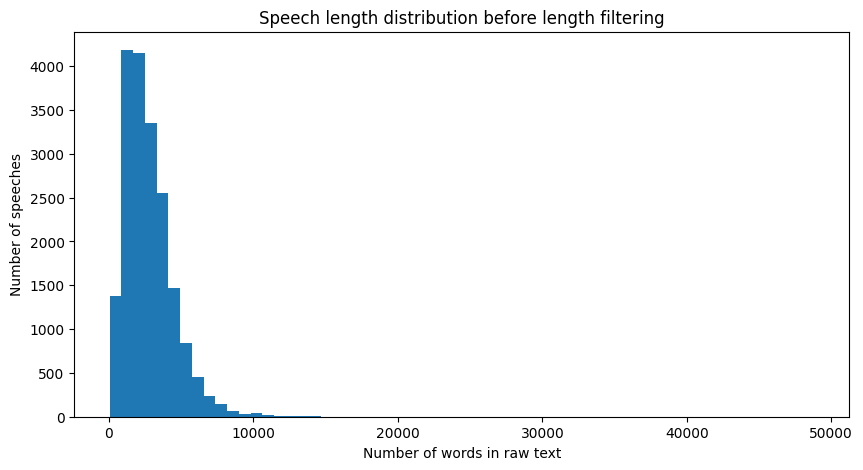

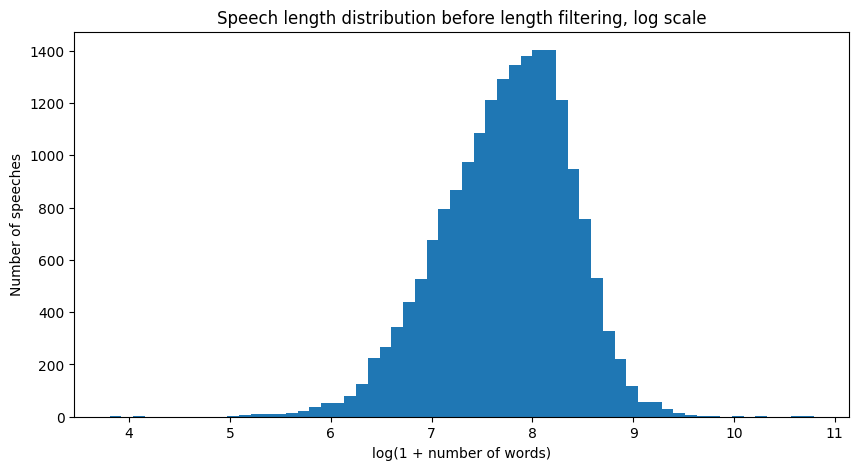

In [14]:
plt.figure(figsize=(10, 5))
plt.hist((df_text["n_words_raw"]), bins=60)
plt.xlabel("Number of words in raw text")
plt.ylabel("Number of speeches")
plt.title("Speech length distribution before length filtering")
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(np.log1p(df_text["n_words_raw"]), bins=60)
plt.xlabel("log(1 + number of words)")
plt.ylabel("Number of speeches")
plt.title("Speech length distribution before length filtering, log scale")
plt.show()

I choose a minimum threshold of **200 raw words**. This removes very short texts while keeping almost all of the corpus. The threshold is conservative because central bank speeches are usually long documents; a document with fewer than 200 words is unlikely to provide enough context for topic modeling.

In [15]:
MIN_RAW_WORDS = 200

df_text = df_text[df_text["n_words_raw"] >= MIN_RAW_WORDS].copy()

print("Shape after filtering short documents:", df_text.shape)
print(f"Share of original dataset kept: {len(df_text) / len(df):.2%}")

Shape after filtering short documents: (18929, 12)
Share of original dataset kept: 97.69%


## 10. Define stopwords

For classical topic modeling methods such as NMF and LDA, I need a cleaned text representation. I remove standard English stopwords and add corpus-specific stopwords.

The corpus-specific stopwords include words that are frequent in central bank speeches but do not help distinguish topics, such as `central`, `bank`, `speech`, `year`, and `time`.

I keep monetary and financial terms such as `inflation`, `policy`, `rate`, `financial`, and `market`, because these words are central to the research question.

In [16]:
standard_stopwords = set(ENGLISH_STOP_WORDS)


domain_stopwords = {
    # Very frequent corpus descriptors
    "central", "bank", "banks", "speech", "speeches",
    "speaker", "governor", "deputy", "mr", "mrs", "ms", "dr",

    # Generic time and discourse words
    "year", "years", "month", "months", "today", "tomorrow",
    "time", "times", "period", "periods", "recent", "currently",

    # Generic words often frequent in formal speeches
    "also", "would", "could", "should", "may", "might", "must",
    "many", "much", "well", "like", "make", "made", "way", "ways",
    "new", "old", "good", "important", "particular", "example",
    "first", "second", "third", "finally", "however", "therefore",
    "indeed", "although", "among", "across", "within", "without",

    # Generic institutional/reporting words
    "report", "reports", "meeting", "meetings", "conference",
    "remarks", "address", "presentation"
}

# I deliberately do not remove economically meaningful words such as:
# inflation, rate, rates, growth, risk, stability, liquidity, credit,
# banking, supervision, climate, digital, global, international.
stopwords = standard_stopwords.union(domain_stopwords)

print("Number of stopwords:", len(stopwords))
print(sorted(list(domain_stopwords))[:50])


Number of stopwords: 362
['across', 'address', 'also', 'although', 'among', 'bank', 'banks', 'central', 'conference', 'could', 'currently', 'deputy', 'dr', 'example', 'finally', 'first', 'good', 'governor', 'however', 'important', 'indeed', 'like', 'made', 'make', 'many', 'may', 'meeting', 'meetings', 'might', 'month', 'months', 'mr', 'mrs', 'ms', 'much', 'must', 'new', 'old', 'particular', 'period', 'periods', 'presentation', 'recent', 'remarks', 'report', 'reports', 'second', 'should', 'speaker', 'speech']


## 11. Clean text for classical topic models

I create a `clean_text` column for TF-IDF, NMF, and LDA.

Compared with the initial simple whitespace tokenization, I now use a more linguistic preprocessing pipeline:

1. lowercase the text;
2. remove URLs and email addresses;
3. protect economically meaningful multi-word expressions such as `monetary_policy`, `financial_stability`, `price_stability`, `exchange_rate`, and `federal_reserve`;
4. tokenize with spaCy;
5. lemmatize each token;
6. keep only core content words: nouns, proper nouns, adjectives and verbs;
7. remove short tokens and stopwords;
8. remove remaining noisy characters while preserving protected expressions.

This representation is designed for classical bag-of-words topic models. The lemmatization step reduces lexical sparsity by mapping inflected forms such as `rates` and `raising` closer to their canonical forms.

In [17]:
# Protected expressions are replaced before spaCy tokenization.
# This helps keep central-banking concepts as single tokens.
protected_replacements = {
    r"2\s*percent": "two_percent",
    r"price\s+stability": "price_stability",
    r"financial\s+stability": "financial_stability",
    r"monetary\s+policy": "monetary_policy",
    r"exchange\s+rate": "exchange_rate",
    r"interest\s+rate": "interest_rate",
    r"federal\s+reserve": "federal_reserve",
    r"euro\s+area": "euro_area",
    r"central\s+bank\s+digital\s+currency": "cbdc",
    r"climate\s+change": "climate_change",
    r"basel\s+iii": "basel_iii",
    r"basel\s+ii": "basel_ii",
    r"covid[-\s]?19": "covid19",
}

allowed_pos = {"NOUN", "PROPN", "ADJ", "VERB"}


def normalize_before_spacy(text):
    if pd.isna(text):
        return ""

    text = str(text).lower()

    # Remove URLs and email addresses
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"\S+@\S+", " ", text)

    # Protect selected economic expressions
    for pattern, replacement in protected_replacements.items():
        text = re.sub(pattern, replacement, text)

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text


def clean_spacy_doc(doc, stopwords):
    tokens = []

    for token in doc:
        if token.is_space or token.is_punct:
            continue

        lemma = token.lemma_.lower().strip()

        # Keep protected multi-word expressions such as monetary_policy
        if "_" in lemma:
            tokens.append(lemma)
            continue

        if token.is_stop:
            continue

        if lemma in stopwords:
            continue

        if len(lemma) <= 2:
            continue

        if lemma.isnumeric():
            continue

        # Keep content-bearing words only
        if token.pos_ not in allowed_pos:
            continue

        # Remove remaining noisy characters, while keeping alphanumeric tokens
        lemma = re.sub(r"[^a-z0-9_]", "", lemma)

        if len(lemma) <= 2:
            continue

        tokens.append(lemma)

    return " ".join(tokens)


texts_for_spacy = df_text["raw_text_stripped"].apply(normalize_before_spacy).tolist()

clean_texts = []
for doc in tqdm(nlp.pipe(texts_for_spacy, batch_size=32, n_process=1), total=len(texts_for_spacy)):
    clean_texts.append(clean_spacy_doc(doc, stopwords))


df_text["clean_text"] = clean_texts
df_text["n_words_clean"] = df_text["clean_text"].apply(lambda x: len(x.split()))

df_text[["raw_text_stripped", "clean_text", "n_words_raw", "n_words_clean"]].head()


  0%|          | 0/18929 [00:00<?, ?it/s]

,raw_text_stripped,clean_text,n_words_raw,n_words_clean
0,Mr. Tietmeyer considers European monetary integration and its implications for the international monetary system Lec...,tietmeyer consider european monetary integration implication international monetary lecture deliver honour professor...,5070,2078
1,Mr Garganas gives a speech on integrating Greece into the euro area and the challenges ahead Speech given by Mr Nich...,garganas integrate greece euro area challenge nicholas garganas greece athens summit september adoption euro common ...,2307,1096
3,"Lucas Papademos: The completion of the changeover to the euro Speech by Mr Lucas Papademos, Governor of the Bank of ...",lucas papademos completion changeover euro lucas papademos greece euro information athens october welcome session eu...,2975,1213
4,"Nicholas Garganas: The Greek economy within the euro area Address by Mr Nicholas C Garganas, Deputy Governor of the ...",nicholas garganas greek economy euro area nicholas garganas greece hellenic american bankers association york april ...,2129,1008
5,"Nicholas C Garganas: The European financial marketplace Speech by Mr Nicholas C Garganas, Governor of the Bank of Gr...",nicholas garganas european financial marketplace nicholas garganas greece economist private banking asset management...,2001,982


### Qualitative check of the cleaned texts

I inspect a few examples before and after preprocessing to verify that the procedure removes noise while keeping economically meaningful vocabulary.

In [19]:
sample_indices = df_text.sample(5, random_state=RANDOM_STATE).index

for idx in sample_indices:
    print("=" * 100)
    print("RAW TEXT:")
    print(df_text.loc[idx, "raw_text_stripped"][:800])
    print("CLEAN TEXT:")
    print(df_text.loc[idx, "clean_text"][:800])


RAW TEXT:
An address by Lesetja Kganyago, Governor of the South African Reserve Bank, at the National Asset and Liability Management Conference London 2 March 2018 Challenges for emerging-market central banks Good morning, ladies and gentlemen, and thank you for the opportunity to address you on some of the challenges facing emerging-market central banks. Since the most recent global financial crisis, central banks have faced mounting challenges. Not only were they at the forefront of saving the global economy from collapse; they were also seen as ‘the only game in town’ in restoring economic growth. Central banks also began to play a more pivotal role in ensuring financial stability in general. With these additional responsibilities and expectations, the independence of central banks became increas
CLEAN TEXT:
lesetja kganyago south african reserve national asset liability management london march challenge emerge market morning lady gentleman thank opportunity challenge face emerge ma

## 12. Create a lighter text version for BERTopic

Transformer-based models can benefit from more natural language context. Therefore, for BERTopic I keep a less aggressively cleaned text column. I remove URLs and extra whitespace, but I do not remove stopwords or punctuation as aggressively as for TF-IDF/NMF/LDA.

In [20]:
def clean_text_for_bertopic(text):
    if pd.isna(text):
        return ""

    text = str(text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"\S+@\S+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text

df_text["bertopic_text"] = df_text["raw_text_stripped"].apply(clean_text_for_bertopic)

df_text[["bertopic_text"]].head()

,bertopic_text
0,Mr. Tietmeyer considers European monetary integration and its implications for the international monetary system Lec...
1,Mr Garganas gives a speech on integrating Greece into the euro area and the challenges ahead Speech given by Mr Nich...
3,"Lucas Papademos: The completion of the changeover to the euro Speech by Mr Lucas Papademos, Governor of the Bank of ..."
4,"Nicholas Garganas: The Greek economy within the euro area Address by Mr Nicholas C Garganas, Deputy Governor of the ..."
5,"Nicholas C Garganas: The European financial marketplace Speech by Mr Nicholas C Garganas, Governor of the Bank of Gr..."


## 13. Filter documents after cleaning

Some texts may become too short after cleaning. I therefore apply a second filter based on the number of cleaned words. This ensures that the documents used by the classical topic models still contain enough vocabulary after stopword removal.

In [21]:
MIN_CLEAN_WORDS = 100

before_clean_filter = len(df_text)

df_model = df_text[df_text["n_words_clean"] >= MIN_CLEAN_WORDS].copy()

after_clean_filter = len(df_model)

print("Documents before cleaned-length filtering:", before_clean_filter)
print("Documents after cleaned-length filtering:", after_clean_filter)
print("Documents removed:", before_clean_filter - after_clean_filter)
print(f"Share of original dataset kept: {len(df_model) / len(df):.2%}")

Documents before cleaned-length filtering: 18929
Documents after cleaned-length filtering: 18922
Documents removed: 7
Share of original dataset kept: 97.66%


## 14. Final corpus diagnostics

I now inspect the final modeling corpus. The goal is to verify that the dataset is still large, temporally rich, and suitable for the next topic modeling notebooks.

In [22]:
final_summary = {
    "raw_observations": len(df),
    "after_missing_and_empty_text_removal": int(text_quality_summary.loc["Non-empty texts", "count"]),
    "after_encoding_quality_filter": after_quality_filter,
    "after_duplicate_and_raw_length_filtering": len(df_text),
    "final_modeling_corpus": len(df_model),
    "share_of_raw_dataset_kept": len(df_model) / len(df),
    "min_year": int(df_model["year"].min()),
    "max_year": int(df_model["year"].max()),
    "n_central_banks": df_model["central_bank"].nunique(),
    "median_clean_words": df_model["n_words_clean"].median(),
    "mean_clean_words": df_model["n_words_clean"].mean(),
}

final_summary_df = pd.DataFrame(
    list(final_summary.items()),
    columns=["quantity", "value"]
)

final_summary_df


,quantity,value
0,raw_observations,19376.000000
1,after_missing_and_empty_text_removal,19185.000000
2,after_encoding_quality_filter,18958.000000
3,after_duplicate_and_raw_length_filtering,18929.000000
4,final_modeling_corpus,18922.000000
5,share_of_raw_dataset_kept,0.976569
6,min_year,1997.000000
7,max_year,2025.000000
8,n_central_banks,118.000000
9,median_clean_words,1093.000000


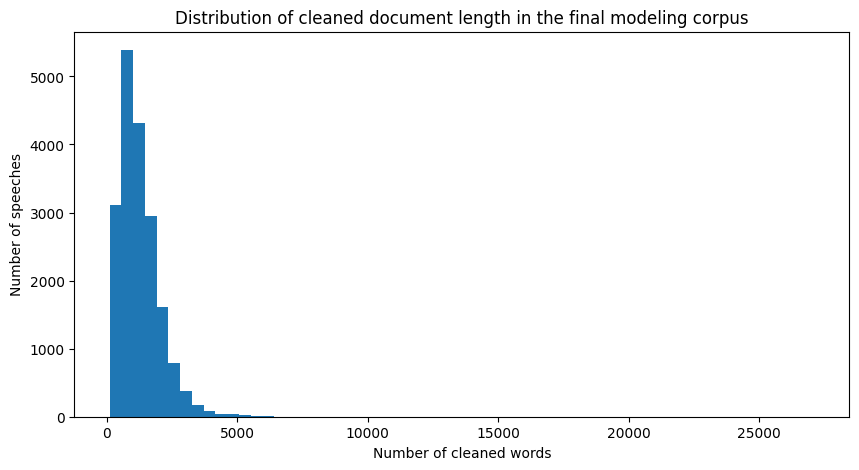

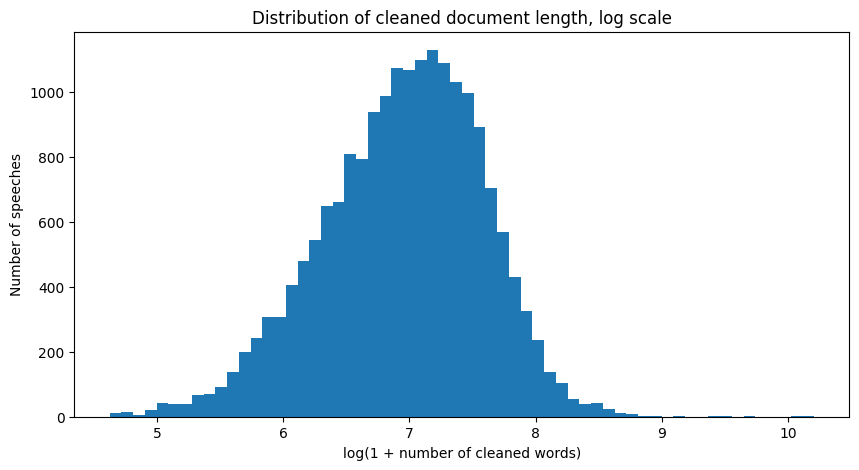

In [23]:
plt.figure(figsize=(10, 5))
plt.hist(df_model["n_words_clean"], bins=60)
plt.xlabel("Number of cleaned words")
plt.ylabel("Number of speeches")
plt.title("Distribution of cleaned document length in the final modeling corpus")
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(np.log1p(df_model["n_words_clean"]), bins=60)
plt.xlabel("log(1 + number of cleaned words)")
plt.ylabel("Number of speeches")
plt.title("Distribution of cleaned document length, log scale")
plt.show()

## 15. Check temporal and institutional coverage after preprocessing

Preprocessing should not strongly distort the temporal or institutional structure of the dataset. I therefore check the number of speeches by year, by macro-financial period, and by central bank after filtering.

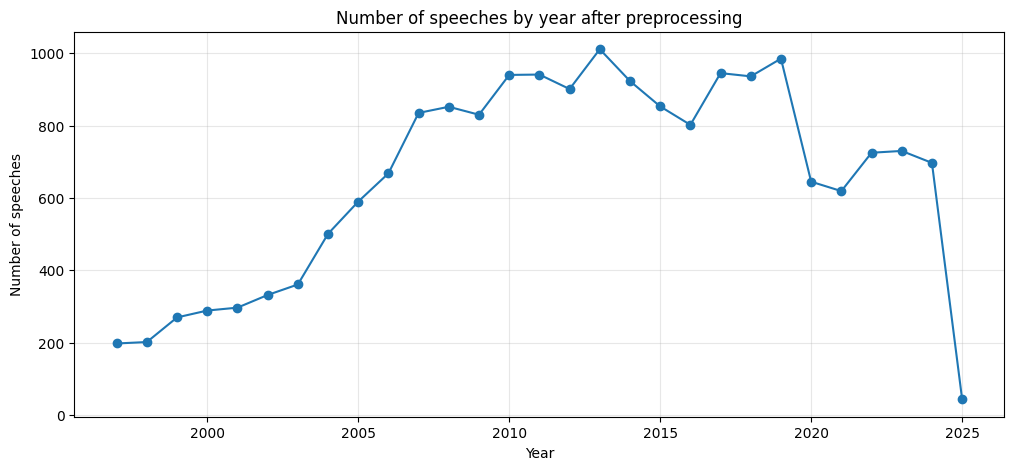

In [24]:
speeches_by_year_clean = (
    df_model.groupby("year")
    .size()
    .reset_index(name="n_speeches")
    .sort_values("year")
)

plt.figure(figsize=(12, 5))
plt.plot(speeches_by_year_clean["year"], speeches_by_year_clean["n_speeches"], marker="o")
plt.xlabel("Year")
plt.ylabel("Number of speeches")
plt.title("Number of speeches by year after preprocessing")
plt.grid(alpha=0.3)
plt.show()

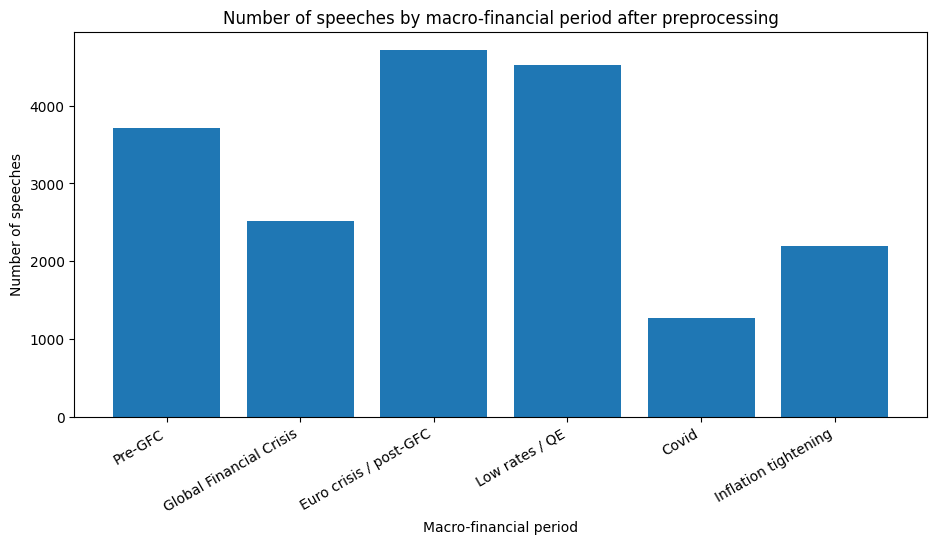

,macro_period,n_speeches
0,Pre-GFC,3708
1,Global Financial Crisis,2517
2,Euro crisis / post-GFC,4716
3,Low rates / QE,4521
4,Covid,1264
5,Inflation tightening,2196


In [25]:
period_order = [
    "Pre-GFC",
    "Global Financial Crisis",
    "Euro crisis / post-GFC",
    "Low rates / QE",
    "Covid",
    "Inflation tightening"
]

period_counts_clean = (
    df_model["macro_period"]
    .value_counts()
    .reindex(period_order)
    .dropna()
    .reset_index()
)

period_counts_clean.columns = ["macro_period", "n_speeches"]

plt.figure(figsize=(11, 5))
plt.bar(period_counts_clean["macro_period"], period_counts_clean["n_speeches"])
plt.xlabel("Macro-financial period")
plt.ylabel("Number of speeches")
plt.title("Number of speeches by macro-financial period after preprocessing")
plt.xticks(rotation=30, ha="right")
plt.show()

period_counts_clean

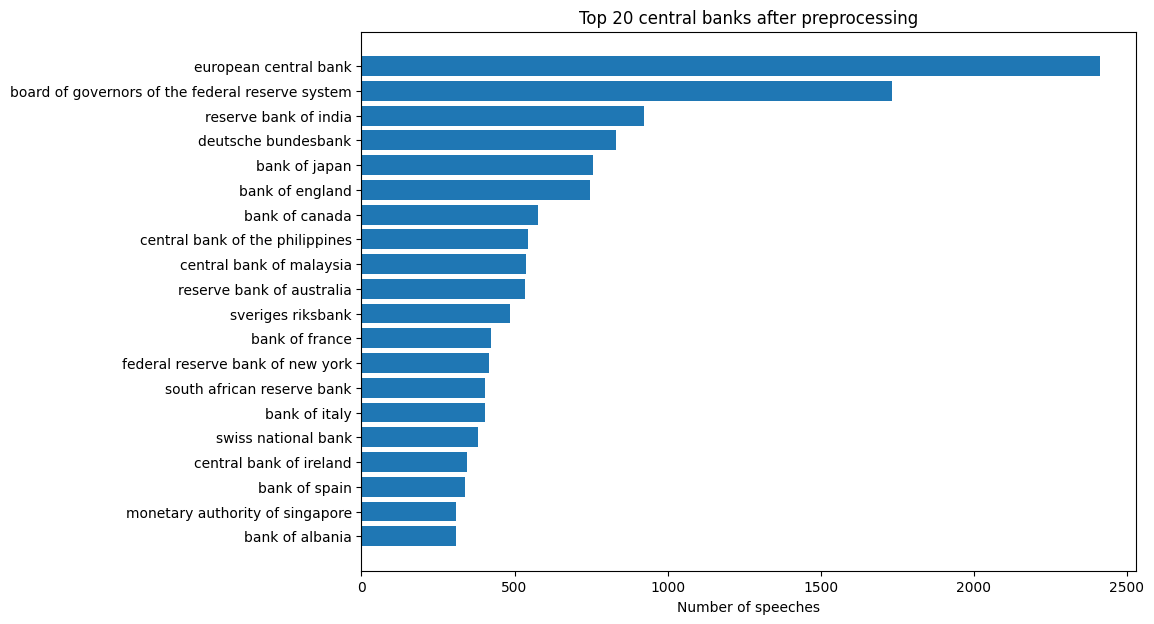

,central_bank,n_speeches
0,european central bank,2411
1,board of governors of the federal reserve system,1732
2,reserve bank of india,922
3,deutsche bundesbank,832
4,bank of japan,755
5,bank of england,747
6,bank of canada,578
7,central bank of the philippines,545
8,central bank of malaysia,537
9,reserve bank of australia,535


In [26]:
top_banks_clean = (
    df_model["central_bank"]
    .value_counts()
    .head(20)
    .reset_index()
)

top_banks_clean.columns = ["central_bank", "n_speeches"]

plt.figure(figsize=(10, 7))
plt.barh(top_banks_clean["central_bank"][::-1], top_banks_clean["n_speeches"][::-1])
plt.xlabel("Number of speeches")
plt.title("Top 20 central banks after preprocessing")
plt.show()

top_banks_clean.head(10)

## 16. Inspect most frequent words after final cleaning

I now check the most frequent words in the final `clean_text` column. This helps verify that the cleaning removed generic terms while preserving monetary and financial vocabulary.

In [27]:
all_clean_tokens = []

for text in tqdm(df_model["clean_text"]):
    all_clean_tokens.extend(text.split())

clean_word_counts = Counter(all_clean_tokens)
top_clean_words = pd.DataFrame(clean_word_counts.most_common(40), columns=["word", "count"])

top_clean_words.head(30)

  0%|          | 0/18922 [00:00<?, ?it/s]

,word,count
0,financial,327830
1,policy,250569
2,market,235617
3,rate,208335
4,risk,169255
5,monetary,165243
6,economy,164031
7,economic,157144
8,inflation,155096
9,price,138431


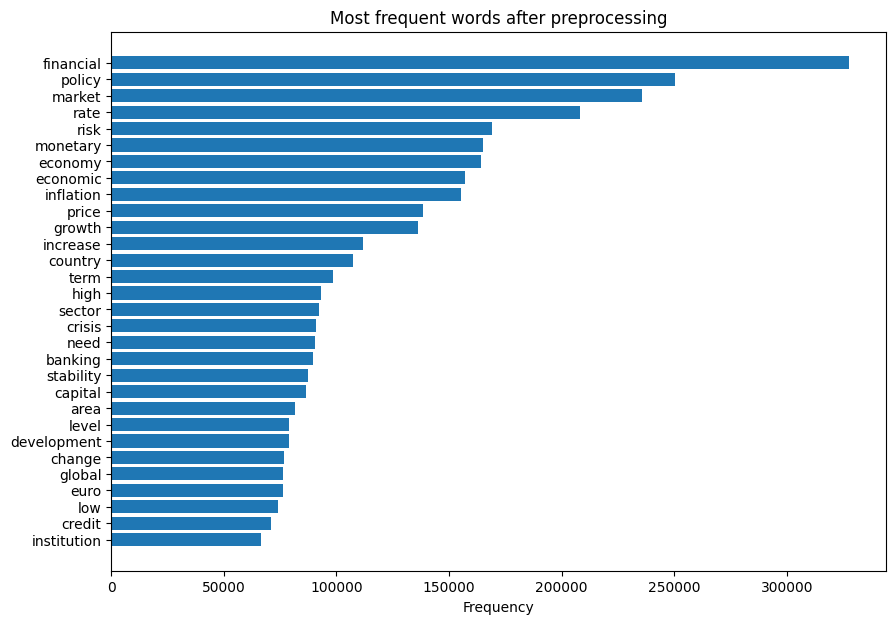

In [28]:
plt.figure(figsize=(10, 7))
plt.barh(top_clean_words["word"].head(30)[::-1], top_clean_words["count"].head(30)[::-1])
plt.xlabel("Frequency")
plt.title("Most frequent words after preprocessing")
plt.show()

The most frequent words after preprocessing should still include meaningful terms such as `financial`, `policy`, `monetary`, `inflation`, `market`, `growth`, `rate`, `risk`, and `stability`. This indicates that the cleaning process preserves the vocabulary needed for monetary-policy topic modeling.

## 17. Keep useful columns for the following notebooks

I keep both versions of the text:

- `clean_text` for TF-IDF, NMF, and LDA;
- `bertopic_text` for BERTopic.

I also keep the key metadata needed for temporal and institutional analysis.

In [29]:
columns_to_keep = [
    "description",
    "raw_text_stripped",
    "clean_text",
    "bertopic_text",
    "central_bank",
    "year",
    "month",
    "macro_period",
    "n_words_raw",
    "n_characters_raw",
    "n_words_clean"
]

df_model = df_model[columns_to_keep].reset_index(drop=True)

df_model.head()

,description,raw_text_stripped,clean_text,bertopic_text,central_bank,year,month,macro_period,n_words_raw,n_characters_raw,n_words_clean
0,"Lecture delivered in honour of Professor Xenophon Zolotas, Honorary Governor of the Bank of Greece, by the President...",Mr. Tietmeyer considers European monetary integration and its implications for the international monetary system Lec...,tietmeyer consider european monetary integration implication international monetary lecture deliver honour professor...,Mr. Tietmeyer considers European monetary integration and its implications for the international monetary system Lec...,bank of greece,1997,10,Pre-GFC,5070,31212,2078
1,"Speech given by Mr Nicholas C Garganas, Deputy Governor of the Bank of Greece, at the 'Athens Summit 1999' on 18 Sep...",Mr Garganas gives a speech on integrating Greece into the euro area and the challenges ahead Speech given by Mr Nich...,garganas integrate greece euro area challenge nicholas garganas greece athens summit september adoption euro common ...,Mr Garganas gives a speech on integrating Greece into the euro area and the challenges ahead Speech given by Mr Nich...,bank of greece,1999,9,Pre-GFC,2307,14497,1096
2,"Speech by Mr Lucas Papademos, Governor of the Bank of Greece, at the Euro Information Conference, Athens, 17 October...","Lucas Papademos: The completion of the changeover to the euro Speech by Mr Lucas Papademos, Governor of the Bank of ...",lucas papademos completion changeover euro lucas papademos greece euro information athens october welcome session eu...,"Lucas Papademos: The completion of the changeover to the euro Speech by Mr Lucas Papademos, Governor of the Bank of ...",bank of greece,2001,10,Pre-GFC,2975,18231,1213
3,"Address by Mr Nicholas C Garganas, Deputy Governor of the Bank of Greece, to the Hellenic American Bankers Associati...","Nicholas Garganas: The Greek economy within the euro area Address by Mr Nicholas C Garganas, Deputy Governor of the ...",nicholas garganas greek economy euro area nicholas garganas greece hellenic american bankers association york april ...,"Nicholas Garganas: The Greek economy within the euro area Address by Mr Nicholas C Garganas, Deputy Governor of the ...",bank of greece,2002,5,Pre-GFC,2129,13387,1008
4,"Speech by Mr Nicholas C Garganas, Governor of the Bank of Greece, at The Economist Conference: Private Banking and A...","Nicholas C Garganas: The European financial marketplace Speech by Mr Nicholas C Garganas, Governor of the Bank of Gr...",nicholas garganas european financial marketplace nicholas garganas greece economist private banking asset management...,"Nicholas C Garganas: The European financial marketplace Speech by Mr Nicholas C Garganas, Governor of the Bank of Gr...",bank of greece,2002,10,Pre-GFC,2001,13166,982


## 18. Save the preprocessed dataset

Even if the analysis is conducted in notebooks, saving the cleaned dataset is useful because the next notebooks can start directly from the same modeling corpus. This also improves reproducibility.

In [30]:
output_path = "bis_speeches_preprocessed.csv"

df_model.to_csv(output_path, index=False)

print(f"Saved preprocessed dataset to: {output_path}")
print("Final shape:", df_model.shape)

Saved preprocessed dataset to: bis_speeches_preprocessed.csv
Final shape: (18922, 11)


In [31]:
from google.colab import files

files.download("bis_speeches_preprocessed.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 19. Conclusion of the preprocessing step

The preprocessing pipeline removes missing or empty texts, severely corrupted documents, exact duplicates, very short documents, and documents that become too short after cleaning. It also creates two text representations:

- a lemmatized bag-of-words representation for TF-IDF/NMF and LDA;
- a lighter text representation preserving more natural language context for BERTopic.

The final dataset is saved as `bis_speeches_preprocessed.csv` and is used as the common input for the next modeling notebooks.